# Project - End-to-End Analysis Case Study

# Data Cleaning

#### 1. Load and Inspect the Dataset

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Load the dataset
df = pd.read_csv('Sample data (1).csv')
df

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.00,3,350,529550.00,0.00,529550.00,393380.00,136170.00,1-Dec-14,12,December,2014
1,Government,Germany,Paseo,NaN,1006.00,10,350,352100.00,0.00,352100.00,261560.00,90540.00,1-Jun-14,6,June,2014
2,Government,Canada,Paseo,NaN,1725.00,10,350,603750.00,0.00,603750.00,448500.00,155250.00,1-Nov-13,11,November,2013
3,Government,Germany,Paseo,NaN,1513.00,10,350,529550.00,0.00,529550.00,393380.00,136170.00,1-Dec-14,12,December,2014
4,Government,Germany,Velo,NaN,1006.00,120,350,352100.00,0.00,352100.00,261560.00,90540.00,1-Jun-14,6,June,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Midmarket,Canada,Paseo,High,1614.00,10,15,24210.00,3631.50,20578.50,16140.00,4438.50,1-Apr-14,4,April,2014
696,Midmarket,Canada,Paseo,High,2559.00,10,15,38385.00,5757.75,32627.25,25590.00,7037.25,1-Aug-14,8,August,2014
697,Enterprise,Germany,Paseo,High,1085.00,10,125,135625.00,20343.75,115281.25,130200.00,-14918.75,1-Oct-14,10,October,2014
698,Midmarket,Germany,Paseo,High,1175.00,10,15,17625.00,2643.75,14981.25,11750.00,3231.25,1-Oct-14,10,October,2014


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    str    
 1   Country              700 non-null    str    
 2   Product              700 non-null    str    
 3   Discount Band        647 non-null    str    
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    int64  
 6   Sale Price           700 non-null    int64  
 7   Gross Sales          700 non-null    float64
 8   Discounts            700 non-null    float64
 9    Sales               700 non-null    float64
 10  COGS                 700 non-null    float64
 11  Profit               700 non-null    float64
 12  Date                 700 non-null    str    
 13  Month Number         700 non-null    int64  
 14  Month Name           700 non-null    str    
 15  Year                 700 non-null    int64  
dtypes

#### 2. View the Actual Duplicate Rows
To see the rows that are duplicated so you can inspect them:

In [42]:
# Keep='false' shows all instances of the duplicated rows
duplicate_rows = df[df.duplicated(keep=False)]

display(duplicate_rows)

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year


#### a) Is null ?

In [43]:
df.isnull().sum()

Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

In [44]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.00,3,350,529550.00,0.00,529550.00,393380.00,136170.00,1-Dec-14,12,December,2014
1,Government,Germany,Paseo,NaN,1006.00,10,350,352100.00,0.00,352100.00,261560.00,90540.00,1-Jun-14,6,June,2014
2,Government,Canada,Paseo,NaN,1725.00,10,350,603750.00,0.00,603750.00,448500.00,155250.00,1-Nov-13,11,November,2013
3,Government,Germany,Paseo,NaN,1513.00,10,350,529550.00,0.00,529550.00,393380.00,136170.00,1-Dec-14,12,December,2014
4,Government,Germany,Velo,NaN,1006.00,120,350,352100.00,0.00,352100.00,261560.00,90540.00,1-Jun-14,6,June,2014


#### b) **Cecking** each column for mixed value types

In [45]:
# 1. Check the general data type assigned to each column
print(df.dtypes)

print("\n-------------------------\n")

# 2. Check for mixed Python types within the same column
for col in df.columns:
    unique_types = df[col].apply(type).unique()
    print(f"Column '{col}': {[t.__name__ for t in unique_types]}")

Segment                    str
Country                    str
Product                    str
Discount Band              str
Units Sold             float64
Manufacturing Price      int64
Sale Price               int64
Gross Sales            float64
Discounts              float64
 Sales                 float64
COGS                   float64
Profit                 float64
Date                       str
Month Number             int64
Month Name                 str
Year                     int64
dtype: object

-------------------------

Column 'Segment': ['str']
Column 'Country': ['str']
Column 'Product': ['str']
Column 'Discount Band': ['float', 'str']
Column 'Units Sold': ['float']
Column 'Manufacturing Price': ['int']
Column 'Sale Price': ['int']
Column 'Gross Sales': ['float']
Column 'Discounts': ['float']
Column ' Sales': ['float']
Column 'COGS': ['float']
Column 'Profit': ['float']
Column 'Date': ['str']
Column 'Month Number': ['int']
Column 'Month Name': ['str']
Column 'Year': ['int'

Only Column 'Discount Band" has mixed type ['float', 'str']

#### c) **Whats is in 'Discount Band" column?**

In [46]:
df['Discount Band'].unique()

<ArrowStringArray>
[nan, 'Low', 'Medium', 'High']
Length: 4, dtype: str

#### d) Get all null (NaN) rows

In [47]:
# Filter rows where 'Discount Band' is NaN (null)
nan_discount_rows = df[df['Discount Band'].isna()]    # isna() means NaN or null

# View the count and first few rows
print(f"Total rows with NaN Discount Band: {len(nan_discount_rows)}")
nan_discount_rows.head()

Total rows with NaN Discount Band: 53


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.00,3,350,529550.00,0.00,529550.00,393380.00,136170.00,1-Dec-14,12,December,2014
1,Government,Germany,Paseo,NaN,1006.00,10,350,352100.00,0.00,352100.00,261560.00,90540.00,1-Jun-14,6,June,2014
2,Government,Canada,Paseo,NaN,1725.00,10,350,603750.00,0.00,603750.00,448500.00,155250.00,1-Nov-13,11,November,2013
3,Government,Germany,Paseo,NaN,1513.00,10,350,529550.00,0.00,529550.00,393380.00,136170.00,1-Dec-14,12,December,2014
4,Government,Germany,Velo,NaN,1006.00,120,350,352100.00,0.00,352100.00,261560.00,90540.00,1-Jun-14,6,June,2014


#### 2. Clean the Dataset

In [48]:
# Clean column names (strip trailing/leading spaces)
df.columns = df.columns.str.strip()

# Handle missing values in 'Discount Band' (replace NaN with 'None')
df['Discount Band'] = df['Discount Band'].fillna('None')

# Convert 'Date' column to datetime format
# Explicitly specify the date format to avoid the UserWarning
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

# Verify cleaning results
print(df.info())
print("\nUnique values in Discount Band:", df['Discount Band'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    str           
 1   Country              700 non-null    str           
 2   Product              700 non-null    str           
 3   Discount Band        700 non-null    str           
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9   Sales                700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[us]
 13  Month Number         700 non-null    int64    

#### a) Checked again for null after cleaning done

In [49]:
df.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

#### 3. Save the cleaned dataset to a new CSV file

In [38]:
df.to_csv('cleaned_retail_sales.csv', index=False)

print("\nCleaned dataset successfully saved as 'cleaned_retail_sales.csv'")


Cleaned dataset successfully saved as 'cleaned_retail_sales.csv'


# Exploratory Data Analysis (EDA)

In [18]:
# Set pandas to show numbers normally (up to 2 decimal places) & not use e scientif format
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [19]:
# Summary statistics for numerical columns
print(df.describe())

       Units Sold  Manufacturing Price  Sale Price  Gross Sales  Discounts  \
count      700.00               700.00      700.00       700.00     700.00   
mean      1608.29                96.48      118.43    182759.43   13150.35   
min        200.00                 3.00        7.00      1799.00       0.00   
25%        905.00                 5.00       12.00     17391.75     800.32   
50%       1542.50                10.00       20.00     37980.00    2585.25   
75%       2229.12               250.00      300.00    279025.00   15956.34   
max       4492.50               260.00      350.00   1207500.00  149677.50   
std        867.43               108.60      136.78    254262.28   22962.93   

           Sales      COGS    Profit                 Date  Month Number  \
count     700.00    700.00    700.00                  700        700.00   
mean   169609.07 145475.21  24133.86  2014-04-28 21:36:00          7.90   
min      1655.08    918.00 -40617.50  2013-09-01 00:00:00          1.00 

Findings : Core Statistical Findings

Sales & Profit Distribution: *The dataset contains 700 transactions spanning across 2013 and 2014. Mean sales per transaction are roughly 169,609 with an average profit of 24,133, though profitability features a wide range (min profit is -40,617 representing financial losses on specific transactions, up to a max profit of 262,200).*

Units Sold: *The average units sold per transaction is 1,608 items, spanning from a minimum of 200 up to 4,492 units.*

#### b) Group By Country with most sales on top

In [20]:
# Total Profit and Sales by Country
country_performance = df.groupby('Country')[['Sales', 'Profit', 'Gross Sales', 'Units Sold']].sum().reset_index().sort_values(by='Sales', ascending=False)
country_performance

,Country,Sales,Profit,Gross Sales,Units Sold
4,United States of America,25029830.16,2995540.67,27269358.00,232627.50
0,Canada,24887654.89,3529228.89,26932163.50,247428.50
1,France,24354172.28,3781020.78,26081674.50,240931.00
2,Germany,23505340.82,3680388.82,24921467.50,201494.00
3,Mexico,20949352.11,2907523.11,22726935.00,203325.00


#### c) Group by Year with most sales on top

In [21]:
#  by Year
year_performance = df.groupby('Year')[['Sales', 'Profit', 'Gross Sales', 'Units Sold']].sum().reset_index().sort_values(by='Sales', ascending=False)
year_performance

,Year,Sales,Profit,Gross Sales,Units Sold
1,2014,92311094.75,13015237.75,99370811.50,861132.00
0,2013,26415255.51,3878464.51,28560787.00,264674.00


#### d) Group by Month with most sales on top

In [22]:
#  by Month
month_performance = df.groupby('Month Name')[['Sales', 'Profit', 'Gross Sales', 'Units Sold']].sum().reset_index().sort_values(by='Sales', ascending=False)
month_performance

,Month Name,Sales,Profit,Gross Sales,Units Sold
10,October,21671431.02,3439781.02,23142112.00,201104.00
2,December,17367228.98,2717329.98,18343293.00,155306.00
9,November,12651417.50,1370102.50,14115248.00,121131.00
11,September,10882697.27,1786735.27,11575053.00,107881.00
6,June,9518893.82,1473753.82,10268972.00,103302.00
5,July,8102920.18,923865.68,8833027.50,69349.00
3,February,7297531.39,1148547.39,7699201.00,55115.00
0,April,6964775.07,929984.57,7429392.50,78886.50
4,January,6607761.68,814028.68,7307403.50,67835.50
8,May,6210211.06,828640.06,6767911.00,51771.00


#### e) Group by Segment with most sales on top

In [23]:
#  by Segment
segment_performance = df.groupby('Segment')[['Sales', 'Profit', 'Gross Sales', 'Units Sold']].sum().reset_index().sort_values(by='Sales', ascending=False)
segment_performance

,Segment,Sales,Profit,Gross Sales,Units Sold
2,Government,52504260.67,11388173.17,56403066.50,470673.50
4,Small Business,42427918.50,4143168.50,45941700.00,153139.00
1,Enterprise,19611694.38,-614545.62,21069000.00,168552.00
3,Midmarket,2381883.08,660103.07,2582670.00,172178.00
0,Channel Partners,1800593.64,1316803.14,1935162.00,161263.50


**Segment Performance Breakdown**

*Government is the largest customer segment, driving over 52.5 million in total sales and generating more than $11.3 million in net profit.*

*Small Business represents the second highest sales driver (42.4M), while Enterprise registers a net negative total profit (-$614,545) across its transaction lines, highlighting an area of structural margin loss.*

#### f) Group by Product with most sales on top

In [24]:
#  by Product
product_performance = df.groupby('Product')[['Sales', 'Profit', 'Gross Sales', 'Units Sold']].sum().reset_index().sort_values(by='Sales', ascending=False)
product_performance

,Product,Sales,Profit,Gross Sales,Units Sold
3,Paseo,33011143.95,4797437.95,35611662.00,338239.50
4,VTT,20511921.02,3034608.02,21968533.50,168783.00
5,Velo,18250059.46,2305992.46,19826768.50,162424.50
0,Amarilla,17747116.06,2814104.06,19037279.50,155315.00
2,Montana,15390801.88,2114754.88,16549834.50,154198.00
1,Carretera,13815307.88,1826804.89,14937520.50,146846.00


**Product Performance Breakdown**

*Paseo is the dominant product line by a significant margin, pulling in over 33 million in sales and ~338,239 units sold.*

*VTT and Velo follow as second and third highest revenue generators, whereas Carretera registers the lowest aggregate sales among the 6 products.*

# Data Visualization

#### 1. Total Sales by Country Bar Chart

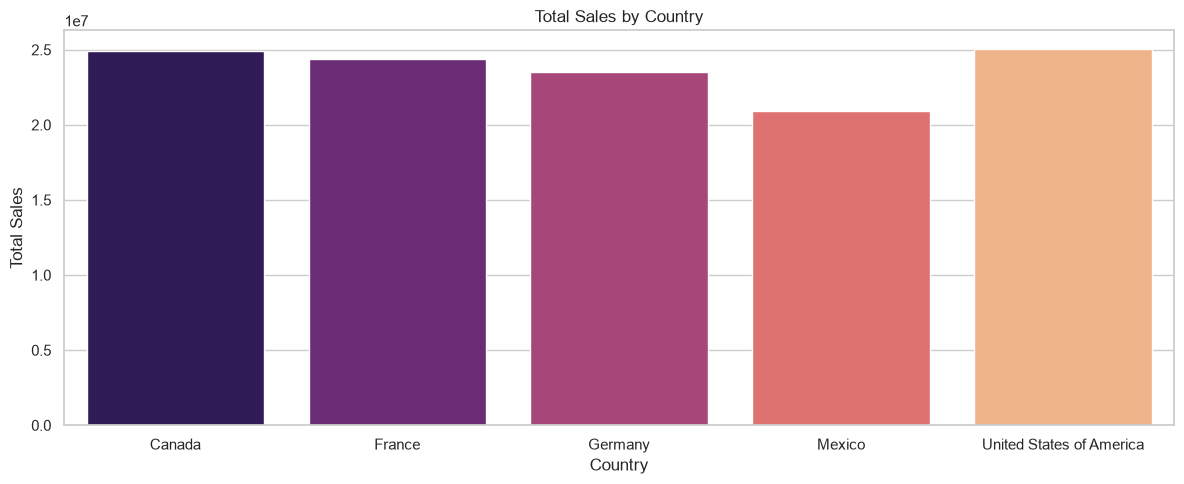

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

country_sales = df.groupby('Country')['Sales'].sum().reset_index()

# Fix applied: hue='Country' and legend=False
sns.barplot(data=country_sales, x='Country', y='Sales', hue='Country', palette='magma', legend=False)

plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The United States of America leads total sales closely followed by Canada and France, while Mexico records the lowest overall performance.

**Sales distribution across the top four countries remains remarkably balanced**, with each generating between USD 23.5 million and USD 25.0 million.

#### 2. Total Profit by Product Bar Chart

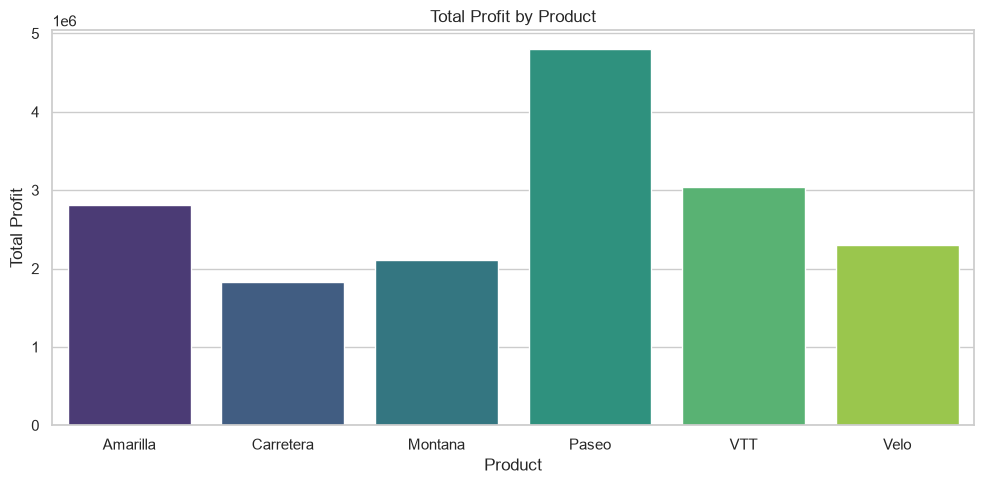

In [26]:
plt.figure(figsize=(10, 5))

product_profit = df.groupby('Product')['Profit'].sum().reset_index()

# Fix applied: hue='Product' and legend=False
sns.barplot(data=product_profit, x='Product', y='Profit', hue='Product', palette='viridis', legend=False)

plt.title('Total Profit by Product')
plt.xlabel('Product')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

**Paseo** generated the highest total profit by a wide margin, whereas Carretera recorded the lowest profitability among all products

#### 3. Segment Sales Bar Chart

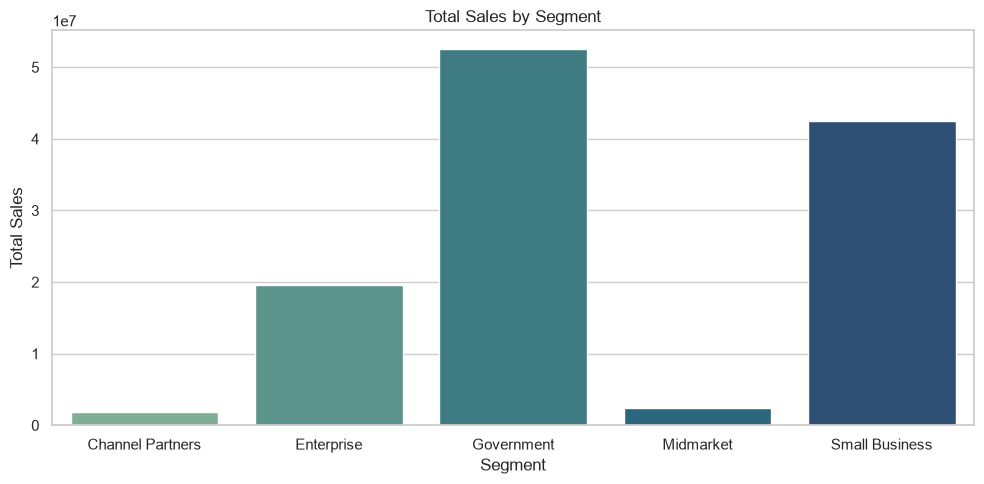

In [27]:
plt.figure(figsize=(10, 5))
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()
sns.barplot(data=segment_sales, x='Segment', y='Sales', hue='Segment', palette='crest')
plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Government and Small Business** segments drive the vast majority of total sales, significantly outperforming Enterprise, Midmarket, and Channel Partners.

#### 4. Month Sales Bar Chart (Chronological Order)

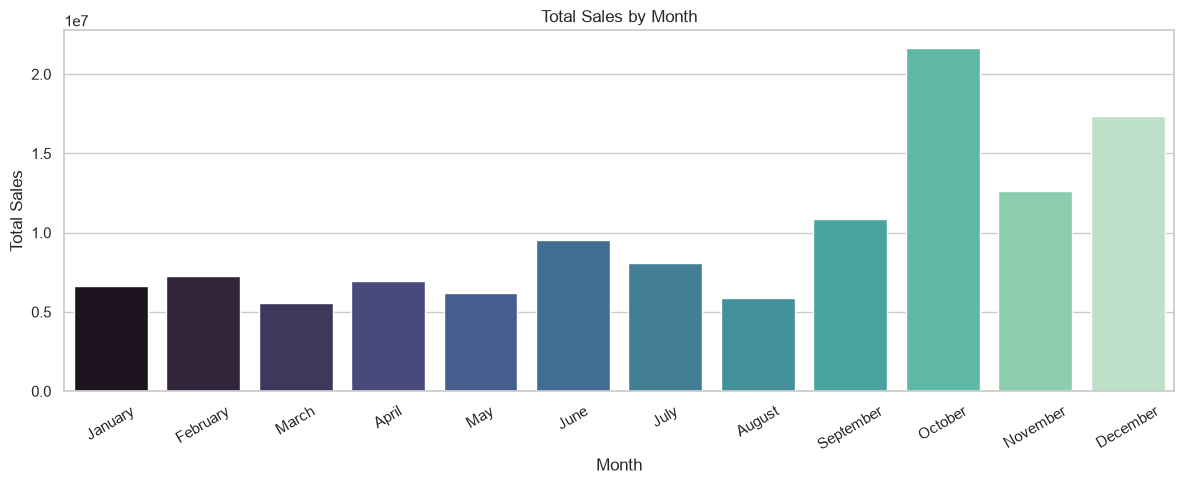

In [28]:
plt.figure(figsize=(12, 5))
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_sales = df.groupby('Month Name')['Sales'].sum().reindex(month_order).reset_index()
sns.barplot(data=month_sales, x='Month Name', y='Sales', hue='Month Name', palette='mako')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Sales peak dramatically during October and December**, while earlier months like March, May, and August experience lower overall sales volume.

#### 5. Year Sales Bar Chart

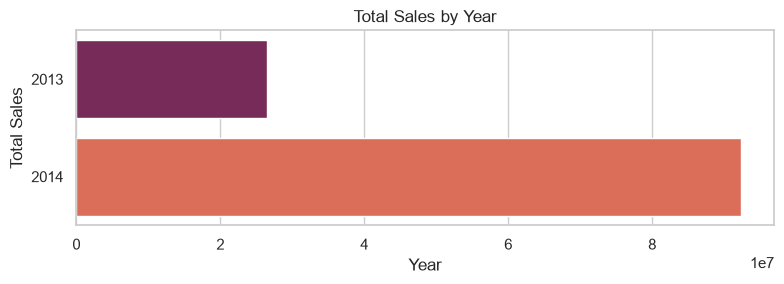

In [29]:
plt.figure(figsize=(8, 3))
year_sales = df.groupby('Year')['Sales'].sum().reset_index()
year_sales['Year'] = year_sales['Year'].astype(str)
sns.barplot(data=year_sales, x= 'Sales', y= 'Year', hue='Year', palette='rocket')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

**Total sales in 2014 expanded significantly** compared to 2013, more than tripling the previous year's annual revenue.

#### 6. Correlation Matrix Heatmap

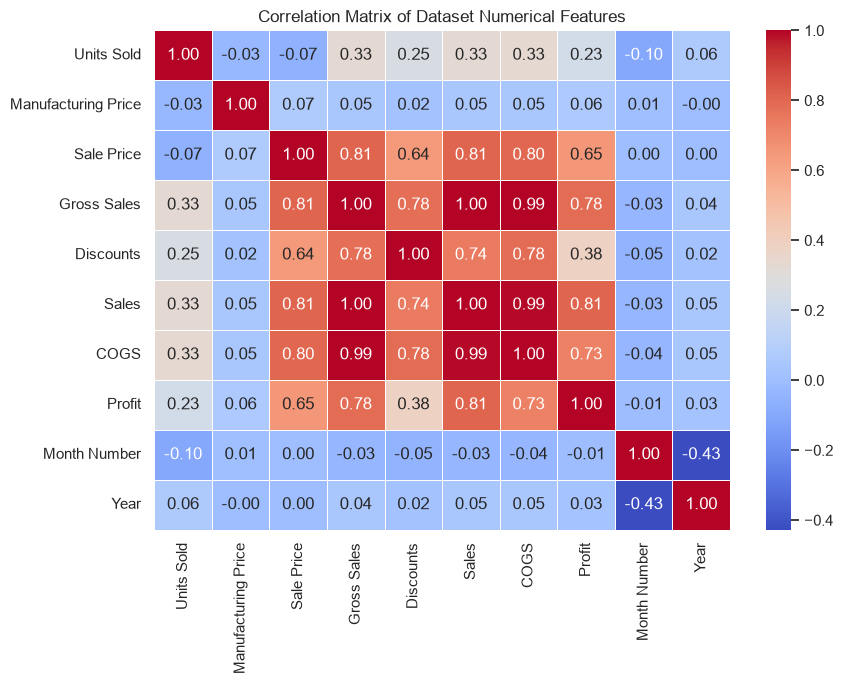

In [30]:
import numpy as np

plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Dataset Numerical Features')
plt.tight_layout()
plt.show()

Key Findings from the Correlation Matrix:

Gross Sales & Sales (r = 0.998): There is a near-perfect positive correlation between Gross Sales and Sales.

Cost of Goods Sold (COGS) & Sales (r = 0.992): COGS scales tightly with Sales and Gross Sales, pointing to a consistent proportional cost baseline for products sold regardless of volume.

Sale Price & Gross Sales (r = 0.808): Higher base sale prices strongly drive up gross sales totals, showing that price point strategy heavily dictates aggregate revenue capacity compared to unit volume alone.

Profit & Sales (r = 0.805): A robust correlation confirms that higher sales volumes successfully translate into higher net profitability across the dataset's transactions.


#### 7. Scatter Plot Code (Units Sold vs Sales)

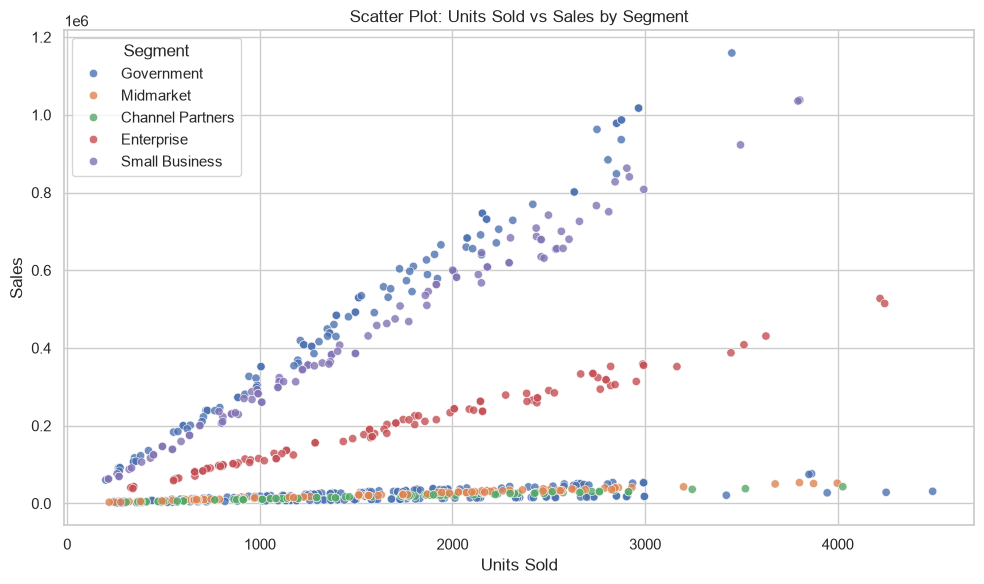

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Units Sold', y='Sales', hue='Segment', palette='deep', alpha=0.8)
plt.title('Scatter Plot: Units Sold vs Sales by Segment')
plt.xlabel('Units Sold')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

**Sales scale positively with units sold across all segments**, featuring distinct pricing tiers that separate **high-volume segments like Government** and **Small Business from lower-tier ones.**

#### 8. Box Plot Code (Profit Distribution by Product)

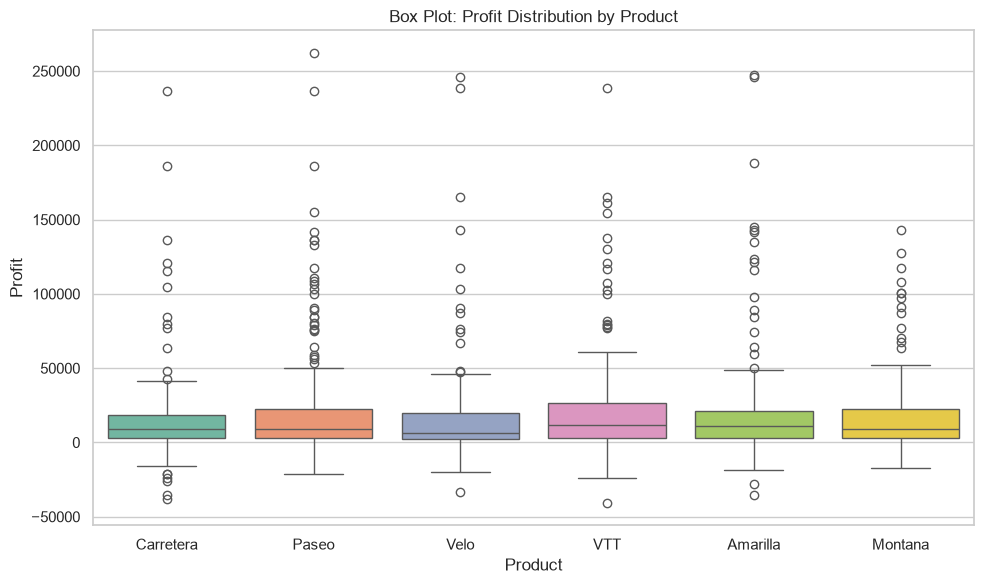

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Product', y='Profit', hue='Product', palette='Set2')
plt.title('Box Plot: Profit Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

**Paseo exhibits the highest profit variability and peak outlier returns**, whereas Carretera and Montana show more conservative and tightly clustered profit distributions.

# Regression model to predict sales.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. Select features and target variable
features = ['Units Sold', 'Gross Sales', 'Profit', 'Country', 'Product', 'Segment']
X = df[features]
y = df['Sales']

# 2. One-hot encode categorical variables for the model
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make predictions and evaluate
y_pred = lr_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)  # Calculates Root Mean Squared Error directly

print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R² Score: 0.9981
Root Mean Squared Error (RMSE): 10250.9157


**R² Score (0.9981):** Indicates that the model explains approximately 99.81% of the variance in sales, demonstrating an extremely strong and accurate fit to the data.

**Root Mean Squared Error (RMSE) (10,250.92):** By bringing the error back into actual dollar amounts, it reveals that your model’s predictions deviate by an average of about $10,250.